   Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1  2010-02-05      24924.50      False        42.31       2.572   
1      1     1  2010-02-12      46039.49       True        38.51       2.548   
2      1     1  2010-02-19      41595.55      False        39.93       2.514   
3      1     1  2010-02-26      19403.54      False        46.63       2.561   
4      1     1  2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   
3        NaN        NaN        NaN        NaN        NaN  211.319643   
4        NaN        NaN        NaN        NaN        NaN  211.350143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         8.106    A  15

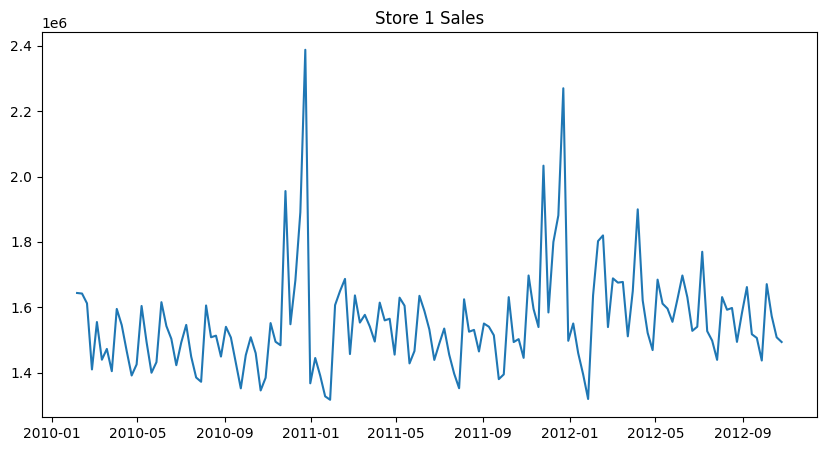

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  122
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1626.368
Date:                Thu, 19 Mar 2026   AIC                           3264.735
Time:                        05:08:22   BIC                           3281.510
Sample:                    02-05-2010   HQIC                          3271.548
                         - 06-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2941      0.046     -6.460      0.000      -0.383      -0.205
ar.L2         -0.2662      0.051     -5.251      0.000      -0.366      -0.167
ar.L3         -0.2426      0.066     -3.676      0.0

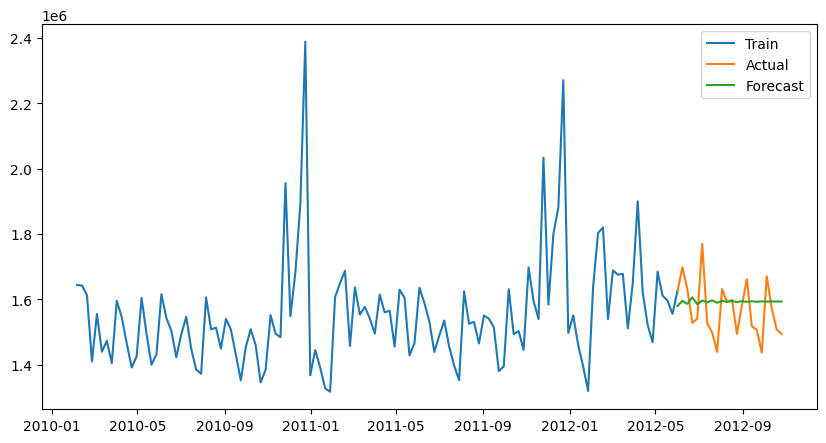

RMSE: 86912.41912369468
MAPE: 4.931451746711229


In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv(r"C:\Users\lovel\Downloads\train.csv.zip")
features = pd.read_csv(r"C:\Users\lovel\Downloads\sales feateures.csv")
stores = pd.read_csv(r"C:\Users\lovel\Downloads\stores.csv")

# Merge train + features
df = pd.merge(train, features, on=['Store', 'Date', 'IsHoliday'])
# Merge with stores data
df = pd.merge(df, stores, on='Store')
print(df.head())

# Convert date
df['Date'] = pd.to_datetime(df['Date'])
# Sort data
df = df.sort_values(by='Date')
# Fill missing values
df.fillna(0, inplace=True)
# Feature engineering
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

store_data = df[df['Store'] == 1]
store_data = store_data.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(store_data)
plt.title("Store 1 Sales")
plt.show()

train_data = store_data[:'2012-06-01']
test_data = store_data['2012-06-01':]

from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_data, order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())

forecast = model_fit.forecast(steps=len(test_data))

plt.figure(figsize=(10,5))
plt.plot(train_data, label="Train")
plt.plot(test_data, label="Actual")
plt.plot(test_data.index, forecast, label="Forecast")
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_data, forecast))
print("RMSE:", rmse)
mape = np.mean(np.abs((test_data - forecast) / test_data)) * 100
print("MAPE:", mape)